In [2]:
import numpy as np
import scipy.stats as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm, ticker
import matplotlib
%matplotlib inline

In [3]:
def p(x,mu,sigma):
    return sp.multivariate_normal.pdf(x, mean=mu, cov=sigma)

def g(n, c, s, x):
    r = np.array([[c, s], [-s, c]])
    return np.matmul(x, np.linalg.matrix_power(r, n))

mu = np.array([0, 0])
sigma = np.array([[1, 0], [0, 1]])

def h(c, s, x):
    r = np.array([[c, s], [-s, c]])
    p0 = p(x, mu, sigma)
    p1 = p(x, np.matmul(mu, r), np.matmul(np.transpose(r), np.matmul(sigma, r)))
    return p0/(p0 + p1)

In [4]:
#MSE7
N = 10**3
generator = np.random.default_rng()
xx = generator.multivariate_normal(mu, sigma, N)
C = 0
S = 0
range = 3
clow = C-range
chigh = C+range
step = 100
slow = S - range
shigh = S + range
alpha = 0.001
e = 10**-20

mylosses= np.zeros((step, step))
i = 0
for s in np.linspace(slow,shigh,step):
    losses = np.zeros(step)
    j = 0
    for c in np.linspace(clow, chigh, step):
        yy = np.array(g(1, c, s, xx))
        losses[j] = np.mean(-np.log(e+h(c,s, xx)) - np.log(e+1.-h(c, s, yy))
                            - alpha*np.linalg.norm((g(7, c, s, xx)-xx))**2
                           )
        j += 1
    mylosses[i] = losses
    i += 1

mylosses -= np.max(mylosses)

In [5]:
c_i =  [0.7754648, -0.68669367, -0.85272074, 0.34041023, 0.05109191, 0.26322436, -0.26031733, 0.9184916, -0.6002579, -0.32182884, -0.9992492, 0.76560736, -0.006189108, 0.10552454, 0.88048744, -0.77696323, -0.418535, 0.05352807, 0.27786446, -0.013198614, 0.38094687, -0.8290806, 0.35008, -0.07130003, -0.017303944, -0.32614326, -0.7450752, -0.8047273, 0.03948307, 0.39553952, 0.33867025, -0.82270575, 0.39858747, 0.51002264, 0.45857978, -0.002630949, 0.47497344, -0.46868038, -0.41669822, -0.56651163, 0.840574, 0.53987527, 0.8776834, -0.36441708, -0.7235334, 0.77164245, 0.7162733, 0.9473314, -0.36006188, 0.5390036]
s_i =  [0.12795448, -0.8351903, 0.54663515, 0.3166659, 0.20901346, -0.86905885, -0.4180193, 0.2509601, -0.8585882, 0.554616, 0.5831325, 0.44919157, -0.76961565, 0.23080754, 0.81703067, 0.7207308, -0.9027374, -0.58535147, -0.35168815, -0.32865167, -0.6052513, 0.988847, 0.95803094, -0.82645345, 0.5462887, 0.7232568, -0.7174337, -0.42856288, -0.38296986, -0.6010468, 0.62368345, -0.32867503, 0.12477422, -0.8286698, 0.17701101, -0.48650336, -0.018068075, -0.6471946, 0.78866506, 0.11960316, 0.14107585, -0.7944603, -0.88299704, -0.5355592, 0.53016496, -0.05969429, -0.25988913, -0.15650153, -0.4398775, -0.8875489]
c_f =  [1.0025189, -0.22466476, -0.9008285, 0.6245249, 0.6201192, 0.62394226, -0.2229284, 1.0004144, -0.22379199, -0.2221647, -0.9019546, 0.6255755, -0.22305427, 0.6219079, 0.6225618, -0.90191066, -0.22281836, -0.22216831, 0.62536484, -0.22092667, 0.62133527, -0.2215939, 0.6263094, -0.22205219, -0.22169948, -0.22068842, -0.9012179, -0.9026136, 0.63052166, 0.62331647, 0.6239745, -0.9005913, 0.623946, 0.625118, 0.62743294, -0.22416058, 0.6219492, -0.22226685, -0.22287042, -0.9015943, 0.9995615, 0.62650377, 0.61998826, -0.2256157, -0.8972939, 1.0035977, 1.0047927, 1.0012878, -0.8957172, 0.624401]
s_f =  [-0.0011163283, -0.9742062, 0.4345404, 0.78244996, 0.7775279, -0.78194016, -0.9749019, -0.00048586668, -0.9730429, 0.9748937, 0.432788, 0.7832417, -0.97857064, 0.7804787, 0.7830722, 0.43164897, -0.9764712, -0.9694825, -0.7846858, -0.9724603, -0.77979547, 0.9746601, 0.78444564, -0.9717784, 0.97420377, 0.97701925, -0.4335694, -0.43561718, -0.7889924, -0.7806294, 0.78094757, -0.43503332, 0.7839696, -0.78312594, 0.7845007, -0.97884077, -0.78119564, -0.9689481, 0.9747142, 0.43369827, -0.00063319755, -0.7814683, -0.7769049, -0.97588164, 0.4319784, 0.0008255972, 0.0023107815, 0.0011525749, -0.43331876, -0.78425926]

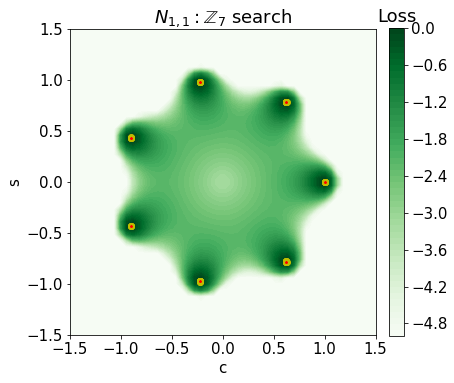

In [37]:
x = np.linspace(clow, chigh, step)
y = np.linspace(slow, shigh, step)
X,Y = np.meshgrid(x,y)
Z = np.array(mylosses)

plt.rc('font', size=15)

fig, ax = plt.subplots(figsize=(6,6))


ax.set_aspect('equal')
ax.set_xlabel('c')
ax.set_ylabel('s')
Z2 = Z.copy()
Z2[Z2<-5] = -5
cf = ax.contourf(X,Y,Z2,50, cmap='Greens')
clb = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
clb.ax.set_title('Loss')
plt.title(r"$N_{1, 1}: \mathbb{Z}_7$ search")
plt.scatter(c_f, s_f, c='y', label="Learned values")
plt.scatter(np.cos(2/7*np.pi*np.arange(7)), np.sin(2/7*np.pi*np.arange(7)), marker='*', c = 'r', s=5)
ax.set_xlim((-1.5, 1.5))
ax.set_ylim((-1.5, 1.5))
#plt.legend()
plt.savefig("C7MSE.pdf",  bbox_inches='tight')
plt.show()